# Part I: Data Ingestion (M1)

From raw Databento OPRA quotes to the per-day Parquet lake that everything
downstream builds on. The quote source is OPRA consolidated NBBO top-of-book
(`cmbp-1`) for all listed SPY options; the underlying is Nasdaq `mbp-1` for
SPY itself.

**Scale.** The initial June panel alone (21 sessions, June 2 to July 1, 2026)
is roughly 858 GB of raw quotes, 44.05 billion records, verified row-for-row
against the vendor's manifest; the full study spans 64 sessions
(March 31 to July 1). That volume lives on the data host. This notebook runs
on the committed dev extract: **one hour of one session** (2026-03-31,
15:00 to 16:00 UTC), which is already 45 million quote messages.

The OPRA data is licensed and not redistributed, so this notebook ships
executed rather than re-runnable.

In [1]:
import os, sys, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The research library and data live in the (private) qfdev_research repo,
# checked out as a sibling of this showcase repo. Override with QFDEV_RESEARCH.
RESEARCH = os.path.abspath(os.environ.get('QFDEV_RESEARCH', '../../qfdev_research'))
assert os.path.isdir(os.path.join(RESEARCH, 'quant')), RESEARCH
sys.path.insert(0, RESEARCH)

plt.rcParams['figure.figsize'] = (10, 4)
pd.set_option('display.width', 160)

DAY = 'spy_20260331'
SAMPLE = os.path.join(RESEARCH, 'quant', 'surface', 'sample', DAY)
print('sample dirs:', sorted(os.listdir(SAMPLE)))

sample dirs: ['opra_cmbp1', 'opra_definition', 'xnas_mbp1_spy']


## Raw OPRA quote messages

Each row is one consolidated top-of-book update for one option contract.
Prices are Databento fixed-point (int64, scale 1e-9); timestamps are
nanoseconds since epoch.

In [2]:
COLS = ['ts_recv_ns', 'instrument_id', 'bid_px_00', 'ask_px_00',
        'bid_sz_00', 'ask_sz_00']
q = pd.read_parquet(glob.glob(os.path.join(SAMPLE, 'opra_cmbp1', 'hour=*', '*.parquet'))[0],
                    columns=COLS)
q['ts'] = pd.to_datetime(q['ts_recv_ns'], utc=True)
print(f"{len(q):,} quote messages | {q['instrument_id'].nunique():,} distinct contracts | "
      f"{q['ts'].min()} .. {q['ts'].max()}")
q.head()

45,233,993 quote messages | 732 distinct contracts | 2026-03-31 15:00:00.000321272+00:00 .. 2026-03-31 16:00:00.000138401+00:00


,ts_recv_ns,instrument_id,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,ts
0,1774969200000321272,1291846099,1660000000,1680000000,113,170,2026-03-31 15:00:00.000321272+00:00
1,1774969200000321272,1291846815,3990000000,4020000000,86,33,2026-03-31 15:00:00.000321272+00:00
2,1774969200000332738,1275069982,8840000000,8940000000,6,62,2026-03-31 15:00:00.000332738+00:00
3,1774969200000401529,1291847579,3290000000,3310000000,173,20,2026-03-31 15:00:00.000401529+00:00
4,1774969200000480505,1224738340,7930000000,7980000000,36,33,2026-03-31 15:00:00.000480505+00:00


## Message rate

Top-of-book updates are extremely bursty; a fixed one-minute snapshot grid is
the first big compression (the production builder reduces hour files to the
last quote per (contract, minute)).

mean 12,562 msg/s | p99 25,664 | max 39,399


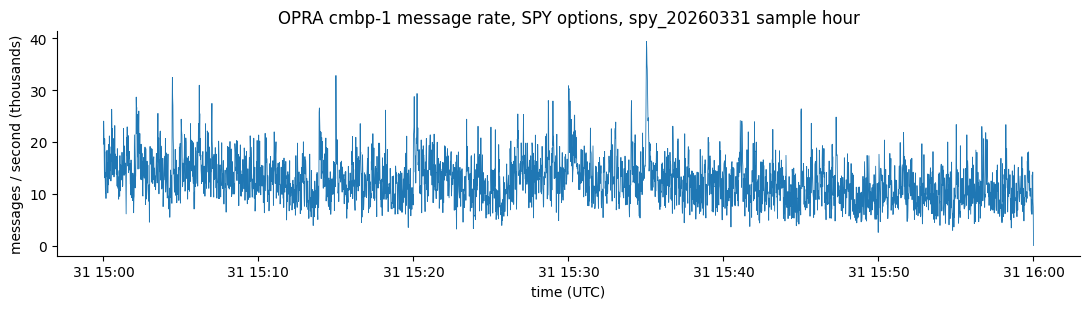

In [3]:
rate = q.set_index('ts').resample('1s').size()
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(rate.index, rate.values / 1e3, lw=0.6)
ax.set_ylabel('messages / second (thousands)')
ax.set_xlabel('time (UTC)')
ax.set_title(f'OPRA cmbp-1 message rate, SPY options, {DAY} sample hour')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
print(f"mean {rate.mean():,.0f} msg/s | p99 {rate.quantile(0.99):,.0f} | max {rate.max():,.0f}")

## Contract universe

The `definition` schema carries the instrument metadata used to decode
`instrument_id`: symbol, expiry, strike, put/call. The study universe is
expiries in the 1 to 45 DTE band.

13,452 option contracts defined | 36 expiries | strikes 50..1360


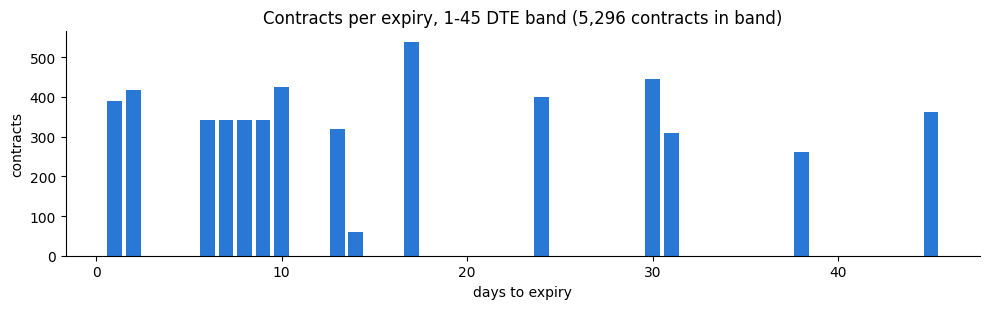

In [4]:
d = pd.read_parquet(os.path.join(SAMPLE, 'opra_definition', 'data.parquet'),
                    columns=['instrument_id', 'raw_symbol', 'instrument_class',
                             'expiration', 'strike_price'])
d = d[d['instrument_class'].isin(['C', 'P'])].copy()
d['expiry'] = pd.to_datetime(d['expiration'], utc=True).dt.date
d['strike'] = d['strike_price'] * 1e-9
sess = pd.Timestamp('2026-03-31').date()
d['dte'] = (pd.to_datetime(d['expiry']) - pd.Timestamp(sess)).dt.days
print(f"{len(d):,} option contracts defined | "
      f"{d['expiry'].nunique()} expiries | strikes {d['strike'].min():.0f}..{d['strike'].max():.0f}")

in_band = d[(d['dte'] >= 1) & (d['dte'] <= 45)]
per_exp = in_band.groupby('dte').size()
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.bar(per_exp.index, per_exp.values, color='#2a78d6')
ax.set_xlabel('days to expiry'); ax.set_ylabel('contracts')
ax.set_title(f'Contracts per expiry, 1-45 DTE band ({len(in_band):,} contracts in band)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

## Underlying

SPY itself comes from Nasdaq `mbp-1`. The builder reduces it to a per-minute
spot series that every option minute joins against (moneyness, forwards,
realized-vol features).

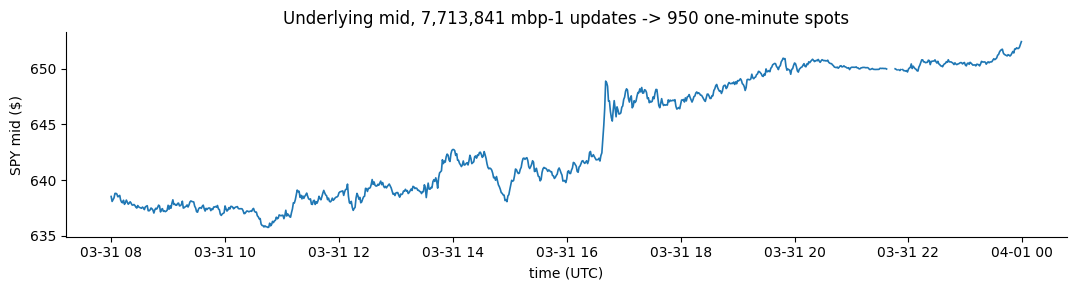

In [5]:
u = pd.read_parquet(os.path.join(SAMPLE, 'xnas_mbp1_spy', 'data.parquet'),
                    columns=['ts_recv_ns', 'bid_px_00', 'ask_px_00'])
u['ts'] = pd.to_datetime(u['ts_recv_ns'], utc=True)
u['mid'] = (u['bid_px_00'] + u['ask_px_00']) / 2 * 1e-9
spot_1m = u.set_index('ts')['mid'].resample('1min').last()
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(spot_1m.index, spot_1m.values, lw=1.2)
ax.set_ylabel('SPY mid ($)'); ax.set_xlabel('time (UTC)')
ax.set_title(f'Underlying mid, {len(u):,} mbp-1 updates -> {spot_1m.notna().sum()} one-minute spots')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

## The one-minute reduction

The core move: for each (contract, minute), keep the **last** quote in the
minute. Below, one liquid contract's raw updates against its one-minute
reduction. Forward-fill onto the continuous minute grid is capped at 5
minutes and every filled row carries quality flags, so staleness is visible
downstream instead of silent.

reduction on this hour, all contracts: 45,233,993 messages -> 41,762 (contract, minute) rows


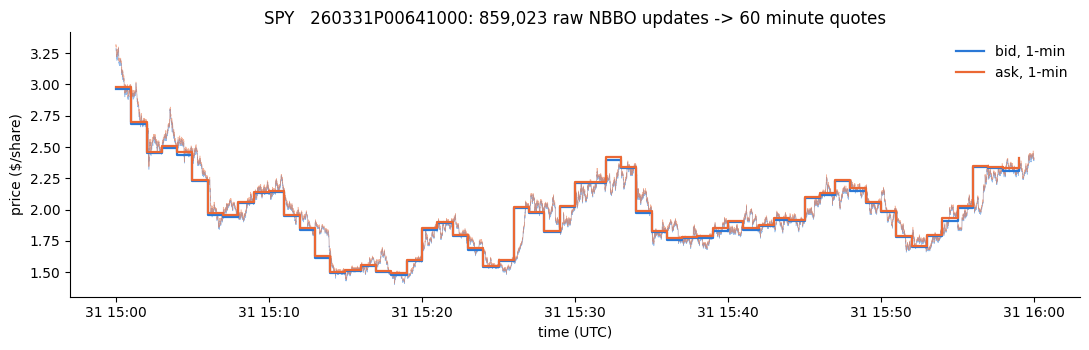

In [6]:
busy = q['instrument_id'].value_counts().index[0]
sym = d.set_index('instrument_id')['raw_symbol'].get(busy, str(busy))
one = q[q['instrument_id'] == busy].sort_values('ts')
one_1m = one.set_index('ts')[['bid_px_00', 'ask_px_00']].resample('1min').last() * 1e-9

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(one['ts'], one['bid_px_00'] * 1e-9, lw=0.4, alpha=0.5, color='#2a78d6')
ax.plot(one['ts'], one['ask_px_00'] * 1e-9, lw=0.4, alpha=0.5, color='#eb6834')
ax.step(one_1m.index, one_1m['bid_px_00'], where='post', lw=1.6, color='#2a78d6', label='bid, 1-min')
ax.step(one_1m.index, one_1m['ask_px_00'], where='post', lw=1.6, color='#eb6834', label='ask, 1-min')
ax.set_ylabel('price ($/share)'); ax.set_xlabel('time (UTC)')
ax.set_title(f'{sym}: {len(one):,} raw NBBO updates -> {one_1m.dropna().shape[0]} minute quotes')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
print(f"reduction on this hour, all contracts: {len(q):,} messages -> "
      f"{q.groupby([q['instrument_id'], q['ts'].dt.floor('1min')]).size().shape[0]:,} (contract, minute) rows")

## What the production pipeline adds

Per session, data-local on the ingestion host: hour-by-hour reduction of the
full chain (every strike and expiry), forward-fill capped at 5 minutes,
two-sided-quote eligibility flags (`0 <= bid <= ask`, positive mid), and the
IV solve. The output is one directory per symbol-day with
`surface_state_1m.parquet` plus metrics and per-contract extracts, which is
exactly what notebook 02 consumes.